<a href="https://colab.research.google.com/github/kashish1720/mldl_lab_sem6/blob/main/exp%208%20/%20mldl_exp8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Training shape: (50000, 32, 32, 3)
Testing shape: (10000, 32, 32, 3)


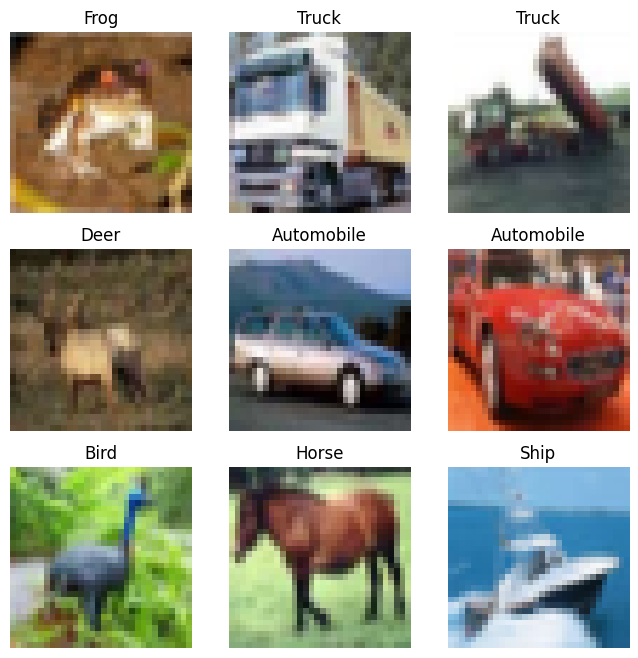

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 85ms/step - accuracy: 0.2684 - loss: 1.9523 - val_accuracy: 0.5021 - val_loss: 1.4027
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 83ms/step - accuracy: 0.4874 - loss: 1.4216 - val_accuracy: 0.5408 - val_loss: 1.2604
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.5615 - loss: 1.2465 - val_accuracy: 0.6166 - val_loss: 1.0791
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.6007 - loss: 1.1276 - val_accuracy: 0.6468 - val_loss: 0.9915
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.6303 - loss: 1.0415 - val_accuracy: 0.6699 - val_loss: 0.9416
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.6662 - loss: 0.9518 - val_accuracy: 0.6679 - val_loss: 0.9417
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 80ms/step - accuracy: 0.6874 - loss: 0.9029 - val_accuracy: 0.6921 - val_loss: 0.8665
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 81ms/step - accuracy: 0.7059 - loss: 0.8485 - 

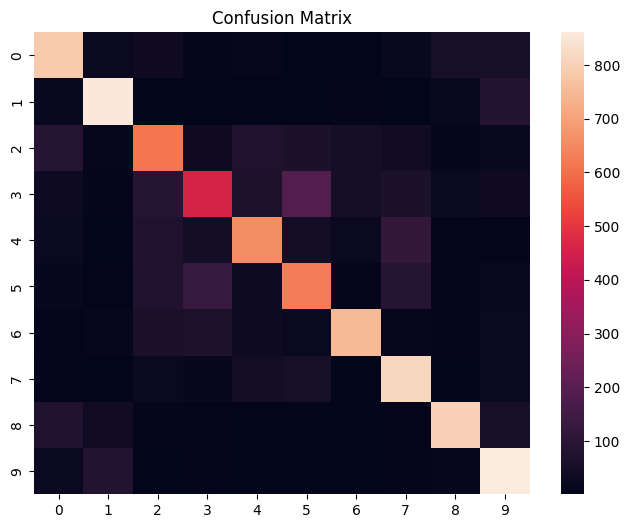


Classification Report:

              precision    recall  f1-score   support

    Airplane       0.73      0.79      0.76      1000
  Automobile       0.82      0.85      0.84      1000
        Bird       0.62      0.61      0.62      1000
         Cat       0.60      0.46      0.52      1000
        Deer       0.71      0.66      0.68      1000
         Dog       0.62      0.63      0.62      1000
        Frog       0.84      0.75      0.79      1000
       Horse       0.70      0.82      0.75      1000
        Ship       0.85      0.80      0.82      1000
       Truck       0.73      0.86      0.79      1000

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.72     10000
weighted avg       0.72      0.72      0.72     10000



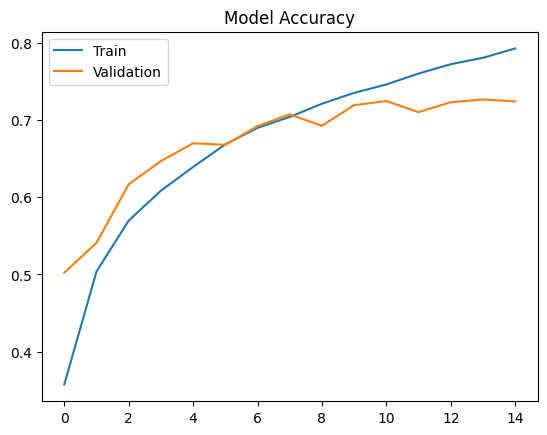

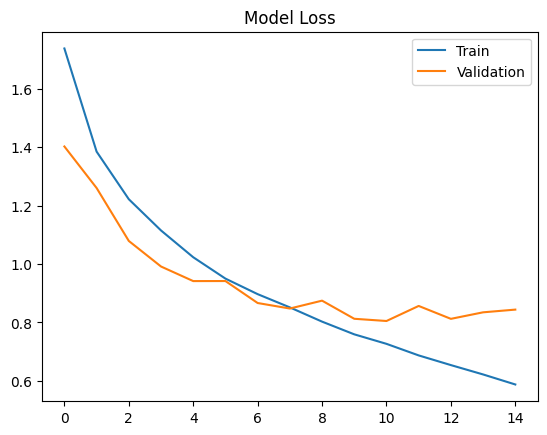

In [ ]:
# ============================================
# CNN ON CIFAR-10 DATASET
# ============================================

import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

# Normalize pixel values (0-255 → 0-1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Class Names
class_names = ['Airplane','Automobile','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']

# Display sample images
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.show()

# Build CNN Model
model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(128, (3,3), activation='relu'),
    keras.layers.Flatten(),

    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation='softmax')
])

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2
)

# Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", accuracy)

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False)
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes, target_names=class_names))

# Plot Accuracy
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(['Train','Validation'])
plt.show()

# Plot Loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.legend(['Train','Validation'])
plt.show()